In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random

Check for GPU

In [ ]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))
#CPU training is slower than GPU because it has fewer cores and performs operations sequentially whereas GPU cores are build for parallel processing.

GPU Available: []


In [ ]:
tf.random.set_seed(42)# Controls randomness in TensorFlow
np.random.seed(42)# Controls randomness in NumPy operations
random.seed(42)# Controls randomness in Python's built-in functions

In [ ]:
from tensorflow.keras.datasets import mnist, cifar10

(x_train_m, y_train_m), (x_test_m, y_test_m) = mnist.load_data()
(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()

print(x_train_m.shape, x_train_c.shape)
print(x_train_m.dtype, np.min(x_train_m), np.max(x_train_m))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28) (50000, 32, 32, 3)
uint8 0 255


In [ ]:
import collections

mnist_class_counts = collections.Counter(y_train_m)

print("MNIST Training Set - Samples per Class:")
for class_label, count in sorted(mnist_class_counts.items()):
    print(f"Class {class_label}: {count} samples")

MNIST Training Set - Samples per Class:
Class 0: 5923 samples
Class 1: 6742 samples
Class 2: 5958 samples
Class 3: 6131 samples
Class 4: 5842 samples
Class 5: 5421 samples
Class 6: 5918 samples
Class 7: 6265 samples
Class 8: 5851 samples
Class 9: 5949 samples


The MNIST dataset is generally considered balanced, as each digit class has a similar number of samples.

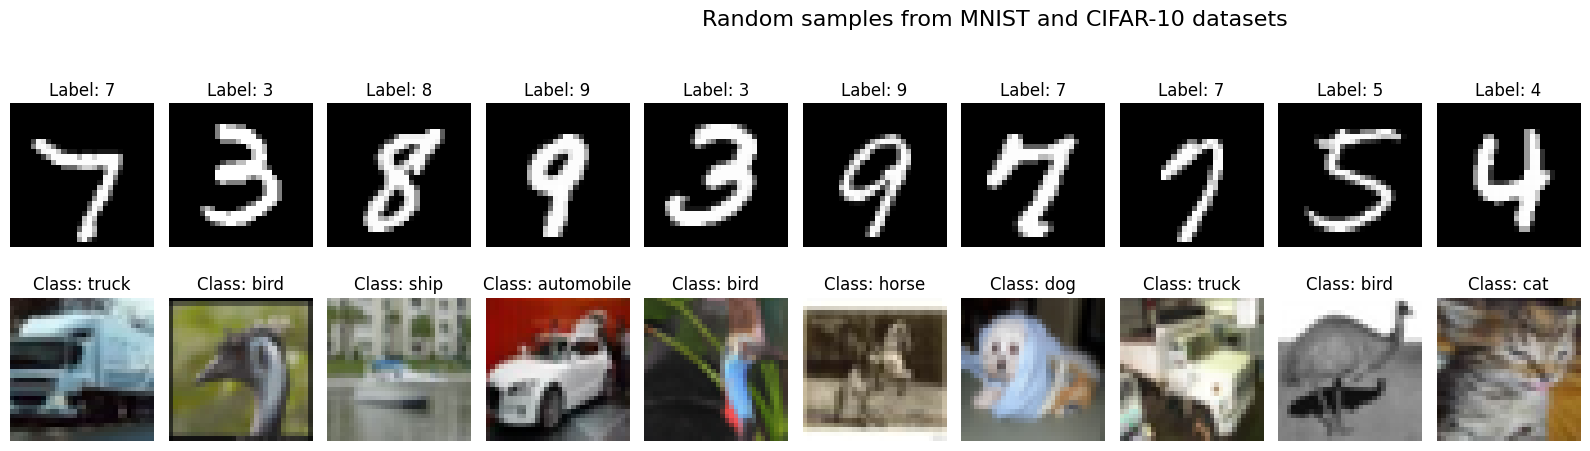

In [ ]:
cifar10_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Random samples from MNIST and CIFAR-10 datasets', fontsize=16)

mnist_indices = np.random.choice(len(x_train_m), 10, replace=False)
for i, idx in enumerate(mnist_indices):
    axes[0, i].imshow(x_train_m[idx], cmap='gray')
    axes[0, i].set_title(f"Label: {y_train_m[idx]}")
    axes[0, i].axis('off')

cifar_indices = np.random.choice(len(x_train_c), 10, replace=False)
for i, idx in enumerate(cifar_indices):
    axes[1, i].imshow(x_train_c[idx])
    class_label = y_train_c[idx][0] if isinstance(y_train_c[idx], np.ndarray) else y_train_c[idx]
    axes[1, i].set_title(f"Class: {cifar10_class_names[class_label]}")
    axes[1, i].axis('off')

plt.tight_layout(rect=[0, 0.03, 0.80, 0.95])
plt.savefig('dataset_samples.png')
plt.show()

In [ ]:
from tensorflow.keras.utils import to_categorical

def preprocess(x, y, is_mnist=True):
    x = x.astype('float32') / 255.0
    print("\n--- After Normalization ---")
    print("x_normalized_m shape:", x.shape)
    print("x_normalized_m sample (first image, top-left pixel):", x[0, 0, 0])
    print("x_normalized_m dtype:", x.dtype)

    if is_mnist:
        x = x.reshape(-1, 28, 28, 1)
        print("\n--- After Reshaping ---")
        print("x_reshaped_m shape:", x.shape)
        print("x_reshaped_m sample (first image, top-left pixel):", x[0, 0, 0])
        print("x_reshaped_m dtype:", x.dtype)

    y = to_categorical(y, 10)
    print("\n--- After One-Hot Encoding ---")
    print("y_onehot_m shape:", y.shape)
    print("y_onehot_m sample (first label):", y[0])
    print("y_onehot_m dtype:", y.dtype)
    return x, y

x_train_m, y_train_m = preprocess(x_train_m, y_train_m)
x_train_c, y_train_c = preprocess(x_train_c, y_train_c, False)


--- After Normalization ---
x_normalized_m shape: (60000, 28, 28)
x_normalized_m sample (first image, top-left pixel): 0.0
x_normalized_m dtype: float32

--- After Reshaping ---
x_reshaped_m shape: (60000, 28, 28, 1)
x_reshaped_m sample (first image, top-left pixel): [0.]
x_reshaped_m dtype: float32

--- After One-Hot Encoding ---
y_onehot_m shape: (60000, 10)
y_onehot_m sample (first label): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
y_onehot_m dtype: float64

--- After Normalization ---
x_normalized_m shape: (50000, 32, 32, 3)
x_normalized_m sample (first image, top-left pixel): [0.23137255 0.24313726 0.24705882]
x_normalized_m dtype: float32

--- After One-Hot Encoding ---
y_onehot_m shape: (50000, 10)
y_onehot_m sample (first label): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
y_onehot_m dtype: float64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


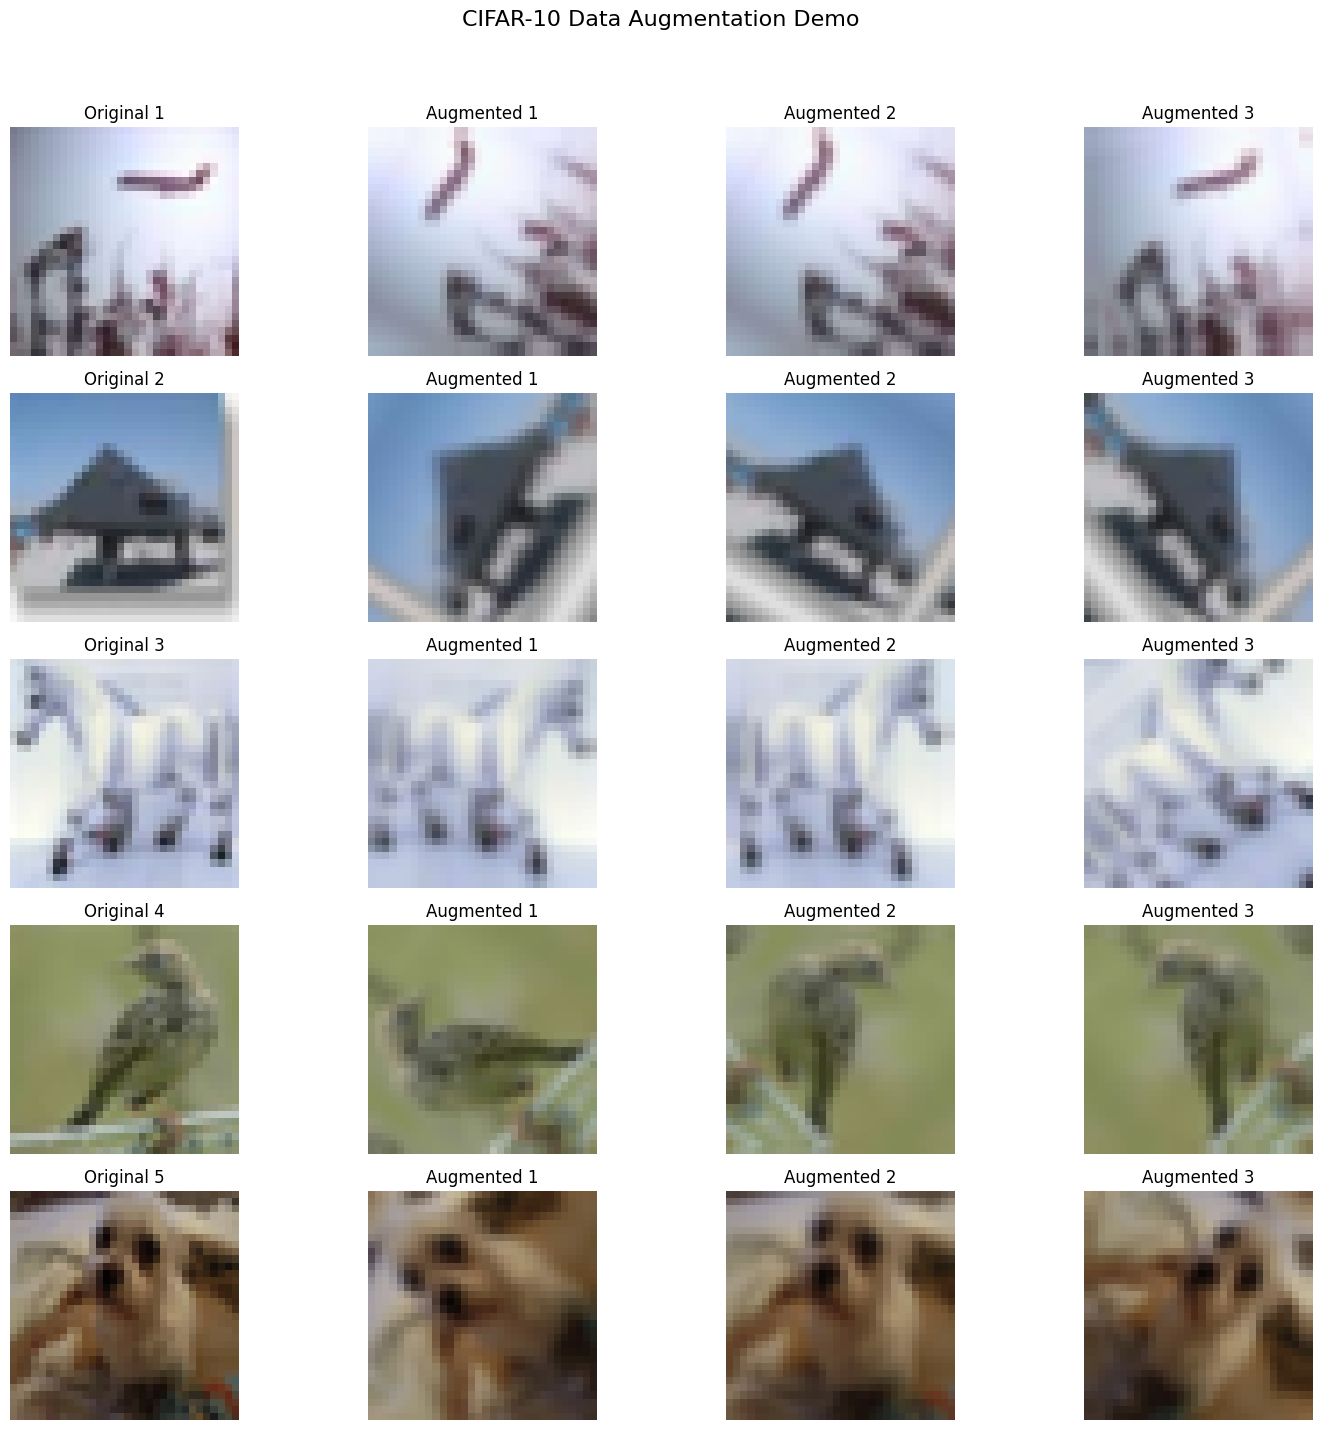

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", input_shape=(32, 32, 3)),
    tf.keras.layers.RandomRotation(factor=0.17453), # ~ +/- 10 degrees (0.17453 radians)
    tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1)
])

num_images = 5
random_indices = np.random.choice(len(x_train_c), num_images, replace=False)

fig, axes = plt.subplots(num_images, 4, figsize=(15, 15))
fig.suptitle('CIFAR-10 Data Augmentation Demo', fontsize=16)

for i, original_idx in enumerate(random_indices):
    original_image = x_train_c[original_idx]
    axes[i, 0].imshow(original_image)
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')

    for j in range(1, 4):
        augmented_image = data_augmentation(tf.expand_dims(original_image, 0))
        axes[i, j].imshow(augmented_image[0])
        axes[i, j].set_title(f'Augmented {j}')
        axes[i, j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('augmentation_demo.png')
plt.show()

Data Augmentation is applied only on Training data to improve generalisation and avoid overfitting. Whereas, it is not applicable on test or validation data beacause the datasets must represent real, unseen data for fair and unbiased evaluation.



Questions:

Q1.What does the channel dimension represent in a tensor of shape (N, H, W, C)?
Explain with reference to both a greyscale image and an RGB image.

ANS. A tensor of shape (N, H, W, C) represents:

      N → number of images (batch size)
      H → height of image
      W → width of image
      C (channel dimension) → number of feature channels per pixel
  The channel dimension (C) is 1 for grayscale images (intensity) and 3 for RGB images (red, green, blue color channels).


Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what data loading strategies would you use to avoid running out of memory? Name at least two techniques and explain how each one helps.

ANS. Training on 1024×1024 images requires much more memory than 32×32, so efficient data handling is necessary.

🔹 Technique 1: Mini-batch Loading

    Load only a small batch of images at a time
    Reduces RAM/GPU memory usage significantly

🔹 Technique 2: Image Resizing / Downsampling

    Resize images to a smaller size while keeping the essential features.
    Faster computation and lower memory consumption

Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation computed from the test set itself. What is wrong with this approach?

ANS. Normalising the test set using its own statistics causes data leakage and leads to biased evaluation; instead, the test set must be normalised using the mean and standard deviation computed from the training data.

TASK 2

In [ ]:
import numpy as np

def conv2d(image, kernel, stride, padding):
    # Get dimensions
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Apply padding
    if padding > 0:
        padded_image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    else:
        padded_image = image

    # Get padded image dimensions
    padded_image_height, padded_image_width = padded_image.shape

    # Calculate output dimensions
    # H_out = floor((H_in - H_k + 2*P) / S) + 1  --> Here H_in already includes padding if any
    output_height = (padded_image_height - kernel_height) // stride + 1
    output_width = (padded_image_width - kernel_width) // stride + 1

    # Initialize output feature map
    feature_map = np.zeros((output_height, output_width))

    # Perform convolution
    for i in range(output_height):
        for j in range(output_width):
            # Extract the image patch
            row_start = i * stride
            col_start = j * stride
            image_patch = padded_image[row_start : row_start + kernel_height,
                                         col_start : col_start + kernel_width]

            # Element-wise multiplication and sum
            feature_map[i, j] = np.sum(image_patch * kernel)

    return feature_map

# Test Image
image = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
])

# Sobel-X Kernel
sobel_x_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Parameters
stride = 1
padding = 0

# Apply convolution
output_feature_map = conv2d(image, sobel_x_kernel, stride, padding)

print("Input Image Shape:", image.shape)
print("Kernel Shape:", sobel_x_kernel.shape)
print("\nOutput Feature Map (Sobel-X):")
print(output_feature_map)

# Verify output shape manually
input_height, input_width = image.shape
kernel_height, kernel_width = sobel_x_kernel.shape

expected_output_height = (input_height - kernel_height) // stride + 1
expected_output_width = (input_width - kernel_width) // stride + 1

print(f"\nExpected Output Shape: ({expected_output_height}, {expected_output_width})")
print("Actual Output Shape:", output_feature_map.shape)

assert output_feature_map.shape == (expected_output_height, expected_output_width)
print("Output shape verification successful!")

Input Image Shape: (5, 5)
Kernel Shape: (3, 3)

Output Feature Map (Sobel-X):
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Expected Output Shape: (3, 3)
Actual Output Shape: (3, 3)
Output shape verification successful!


### Output Size Derivation

The formula for calculating the output spatial dimension (height or width) is:

`Output = floor(((Input - Kernel + 2 * Padding) / Stride)) + 1`

Let's apply this formula to each scenario:

---

**(a) Input: 28×28, Kernel: 5×5, Padding: 0 (valid), Stride: 1**

*   Input Size (H_in, W_in) = 28
*   Kernel Size (H_k, W_k) = 5
*   Padding (P) = 0
*   Stride (S) = 1

**Height Calculation:**
H_out = floor(((28 - 5 + 2 * 0) / 1)) + 1
H_out = floor((23 / 1)) + 1
H_out = 23 + 1
H_out = 24

**Width Calculation:**
W_out = floor(((28 - 5 + 2 * 0) / 1)) + 1
W_out = floor((23 / 1)) + 1
W_out = 23 + 1
W_out = 24

**Output Size: 24×24**

---

**(b) Input: 28×28, Kernel: 3×3, Padding: 1 (same), Stride: 1**

*   Input Size (H_in, W_in) = 28
*   Kernel Size (H_k, W_k) = 3
*   Padding (P) = 1 (for 'same' padding with stride 1, P is typically chosen to make output size equal to input size)
*   Stride (S) = 1

**Height Calculation:**
H_out = floor(((28 - 3 + 2 * 1) / 1)) + 1
H_out = floor(((25 + 2) / 1)) + 1
H_out = floor((27 / 1)) + 1
H_out = 27 + 1
H_out = 28

**Width Calculation:**
W_out = floor(((28 - 3 + 2 * 1) / 1)) + 1
W_out = floor(((25 + 2) / 1)) + 1
W_out = floor((27 / 1)) + 1
W_out = 27 + 1
W_out = 28

**Output Size: 28×28**

---

**(c) Input: 32×32, Kernel: 3×3, Padding: 0 (valid), Stride: 2**

*   Input Size (H_in, W_in) = 32
*   Kernel Size (H_k, W_k) = 3
*   Padding (P) = 0
*   Stride (S) = 2

**Height Calculation:**
H_out = floor(((32 - 3 + 2 * 0) / 2)) + 1
H_out = floor((29 / 2)) + 1
H_out = floor(14.5) + 1
H_out = 14 + 1
H_out = 15

**Width Calculation:**
W_out = floor(((32 - 3 + 2 * 0) / 2)) + 1
W_out = floor((29 / 2)) + 1
W_out = floor(14.5) + 1
W_out = 14 + 1
W_out = 15

**Output Size: 15×15**

---

**(d) Two consecutive Conv2D layers:**

*   **Layer 1:** Input: 32×32, K=3, P=1, S=1

    *   Input Size (H_in, W_in) = 32
    *   Kernel Size (H_k, W_k) = 3
    *   Padding (P) = 1
    *   Stride (S) = 1

    **Height Calculation (Layer 1):**
    H_out1 = floor(((32 - 3 + 2 * 1) / 1)) + 1
    H_out1 = floor(((29 + 2) / 1)) + 1
    H_out1 = floor((31 / 1)) + 1
    H_out1 = 31 + 1
    H_out1 = 32

    **Width Calculation (Layer 1):**
    W_out1 = floor(((32 - 3 + 2 * 1) / 1)) + 1
    W_out1 = floor(((29 + 2) / 1)) + 1
    W_out1 = floor((31 / 1)) + 1
    W_out1 = 31 + 1
    W_out1 = 32

    **Output of Layer 1: 32×32**

*   **Layer 2:** Input: (Output of Layer 1) 32×32, K=3, P=0, S=1

    *   Input Size (H_in, W_in) = 32
    *   Kernel Size (H_k, W_k) = 3
    *   Padding (P) = 0
    *   Stride (S) = 1

    **Height Calculation (Layer 2):**
    H_out2 = floor(((32 - 3 + 2 * 0) / 1)) + 1
    H_out2 = floor((29 / 1)) + 1
    H_out2 = 29 + 1
    H_out2 = 30

    **Width Calculation (Layer 2):**
    W_out2 = floor(((32 - 3 + 2 * 0) / 1)) + 1
    W_out2 = floor((29 / 1)) + 1
    W_out2 = 29 + 1
    W_out2 = 30

**Final Output Size: 30×30**

In [ ]:
import tensorflow as tf

# LeNet-5 Architecture
lenet5_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1), padding='valid'),
    tf.keras.layers.AveragePooling2D((2, 2), strides=(2, 2)),
    tf.keras.layers.Conv2D(16, (5, 5), activation='tanh', padding='valid'),
    tf.keras.layers.AveragePooling2D((2, 2), strides=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(120, activation='tanh'),
    tf.keras.layers.Dense(84, activation='tanh'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Print model summary
lenet5_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

### (b) Manual Parameter Calculation for the First Conv2D layer

The formula for calculating parameters in a convolutional layer is: `(K × K × C_in + 1) × C_out`

Where:
*   `K` = Kernel Size (height or width)
*   `C_in` = Number of input channels
*   `1` = Bias term for each filter
*   `C_out` = Number of output channels (or filters)

For the first `Conv2D` layer in LeNet-5:
*   `K` = 5 (kernel size is 5x5)
*   `C_in` = 1 (input image has 1 channel for grayscale)
*   `C_out` = 6 (number of filters)

Substituting these values into the formula:
Parameters = `(5 × 5 × 1 + 1) × 6`
Parameters = `(25 + 1) × 6`
Parameters = `26 × 6`
Parameters = `156`

This matches the parameter count for the first `conv2d` layer shown in the model summary.

### (c) Explanation of AvgPooling vs. MaxPooling

AvgPooling in LeNet-5:
Used to downsample by taking the average of values, producing smoother feature maps and reducing dimensions while preserving general information.

MaxPooling Today:
More common because it keeps the strongest features (maximum values), improves performance, adds translation invariance, and reduces computation more effectively.

In [ ]:
import tensorflow as tf

def create_custom_cifar10_cnn():
    model = tf.keras.Sequential([
        # Convolutional Block 1
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', input_shape=(32, 32, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Convolutional Block 2
        tf.keras.layers.Conv2D(128, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Convolutional Block 3
        tf.keras.layers.Conv2D(256, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Classification Head
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Create and print the model summary
custom_cifar10_model = create_custom_cifar10_cnn()
custom_cifar10_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440,970 (1.68 MB)

 Trainable params: 440,074 (1.68 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
import tensorflow as tf

def create_custom_cifar10_cnn():
    model = tf.keras.Sequential([
        # Convolutional Block 1
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', input_shape=(32, 32, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Convolutional Block 2
        tf.keras.layers.Conv2D(128, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Convolutional Block 3
        tf.keras.layers.Conv2D(256, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Classification Head
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Create and print the model summary
custom_cifar10_model = create_custom_cifar10_cnn()
custom_cifar10_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440,970 (1.68 MB)

 Trainable params: 440,074 (1.68 MB)

 Non-trainable params: 896 (3.50 KB)

### Custom CNN Architecture for CIFAR-10

**ASCII Diagram:**

```
Input (32x32x3)
    |
    V
Conv2D (64 filters, 3x3, padding='same')
    |
    V
BatchNormalization
    |
    V
ReLU
    |
    V
MaxPooling2D (2x2)
    |
    V
Conv2D (128 filters, 3x3, padding='same')
    |
    V
BatchNormalization
    |
    V
ReLU
    |
    V
MaxPooling2D (2x2)
    |
    V
Conv2D (256 filters, 3x3, padding='same')
    |
    V
BatchNormalization
    |
    V
ReLU
    |
    V
GlobalAveragePooling2D
    |
    V
Dense (256 units, activation='relu')
    |
    V
Dropout (0.5)
    |
    V
Dense (10 units, activation='softmax')
```

**Design Rationale:**
This architecture leverages three convolutional blocks to progressively extract hierarchical features from the CIFAR-10 images. Each block incorporates `BatchNormalization` for faster and more stable training, followed by `ReLU` for non-linearity. `MaxPooling` layers are used to reduce spatial dimensions, increasing the receptive field. A `GlobalAveragePooling2D` layer replaces `Flatten` to reduce the number of parameters and combat overfitting by averaging feature maps into a single vector. Finally, a `Dropout` layer is included in the dense classification head to further enhance regularization and prevent overfitting, leading to a robust model suitable for CIFAR-10 classification within the target parameter range.

Questions:

Q1.Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the same input with the same number of filters. Which uses fewer parameters? Show numerical proof and explain any other advantages of the smaller kernel approach.

ANS. Assume:

Input channels = C           
Output filters = F

Single 5×5 Conv layer:         
Parameters = (5 × 5 × C + 1) × F = (25C + 1)F           
Two stacked 3×3 Conv layers:           
First layer: (3 × 3 × C + 1) × F = (9C + 1)F      
Second layer: (3 × 3 × F + 1) × F = (9F + 1)F        
Total ≈ (9C + 9F + 2)F

Additional Advantages of 3×3 Stacking   
Same receptive field   
Two 3×3 ≈ one 5×5   
More non-linearity   
Two activation layers → better feature learning  
Better performance   
Deeper networks capture more complex patterns    
Reduced overfitting   
Fewer parameters → less risk    

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or after activation), and why? Mention at least two empirical benefits it provides during training.

ANS. Role of Batch Normalisation (BN):

Normalises layer inputs to have mean ≈ 0 and variance ≈ 1
Stabilises training and reduces internal covariate shift

Placement:

Applied after Conv layer and before activation     
Order: Conv → BatchNorm → ReLU   
Reason:
BN normalises raw outputs before non-linearity and
leads to more stable and effective activation

Empirical Benefits:

Faster convergence-
Allows higher learning rates   
Improved stability-
Reduces exploding/vanishing gradients   
Regularisation effect-
Slightly reduces overfitting   
Better performance-
Often improves validation accuracy

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do geometrically? What would happen to the parameter count and spatial information if you replaced it with Flatten?

ANS. Function of GlobalAveragePooling layer:

Converts each feature map into a single value by averaging over H×W      
Geometrically: collapses spatial dimensions (H, W) → keeps only channel-wise information     
Output shape becomes (C) instead of (H × W × C)

If replaced with Flatten:
Parameter count:   
Flatten outputs H × W × C values  
Leads to very large Dense layers → huge increase in parameters

Spatial information:    
Flatten preserves spatial details explicitly     
But treats all pixels independently (no spatial structure awareness)

TASK 3

In [ ]:
import tensorflow as tf

# Assuming x_test_m and y_test_m are still in their raw form (uint8, not one-hot encoded).
# Re-load MNIST test data to ensure we have the raw data for preprocessing if it was modified globally.
(_, _), (x_test_m_raw, y_test_m_raw) = tf.keras.datasets.mnist.load_data()

# Preprocess the test data using the same preprocess function
x_test_m, y_test_m = preprocess(x_test_m_raw, y_test_m_raw, is_mnist=True)

print("\nPreprocessed x_test_m shape:", x_test_m.shape)
print("Preprocessed y_test_m shape:", y_test_m.shape)


--- After Normalization ---
x_normalized_m shape: (10000, 28, 28)
x_normalized_m sample (first image, top-left pixel): 0.0
x_normalized_m dtype: float32

--- After Reshaping ---
x_reshaped_m shape: (10000, 28, 28, 1)
x_reshaped_m sample (first image, top-left pixel): [0.]
x_reshaped_m dtype: float32

--- After One-Hot Encoding ---
y_onehot_m shape: (10000, 10)
y_onehot_m sample (first label): [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
y_onehot_m dtype: float64

Preprocessed x_test_m shape: (10000, 28, 28, 1)
Preprocessed y_test_m shape: (10000, 10)


In [ ]:
# Compile the LeNet-5 model
lenet5_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the LeNet-5 model
history = lenet5_model.fit(
    x_train_m, y_train_m,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.7751 - loss: 0.9101 - val_accuracy: 0.9033 - val_loss: 0.3854
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.8895 - loss: 0.3914 - val_accuracy: 0.9232 - val_loss: 0.2816
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9083 - loss: 0.3160 - val_accuracy: 0.9345 - val_loss: 0.2345
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9212 - loss: 0.2711 - val_accuracy: 0.9462 - val_loss: 0.2024
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9302 - loss: 0.2372 - val_accuracy: 0.9518 - val_loss: 0.1778
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9386 - loss: 0.2097 - val_accuracy: 0.9583 - val_loss: 0.1580
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9452 - loss: 0.1868 - val_accuracy: 0.9628 - val_loss: 0.1419
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.9505 - loss: 0.1677 - 

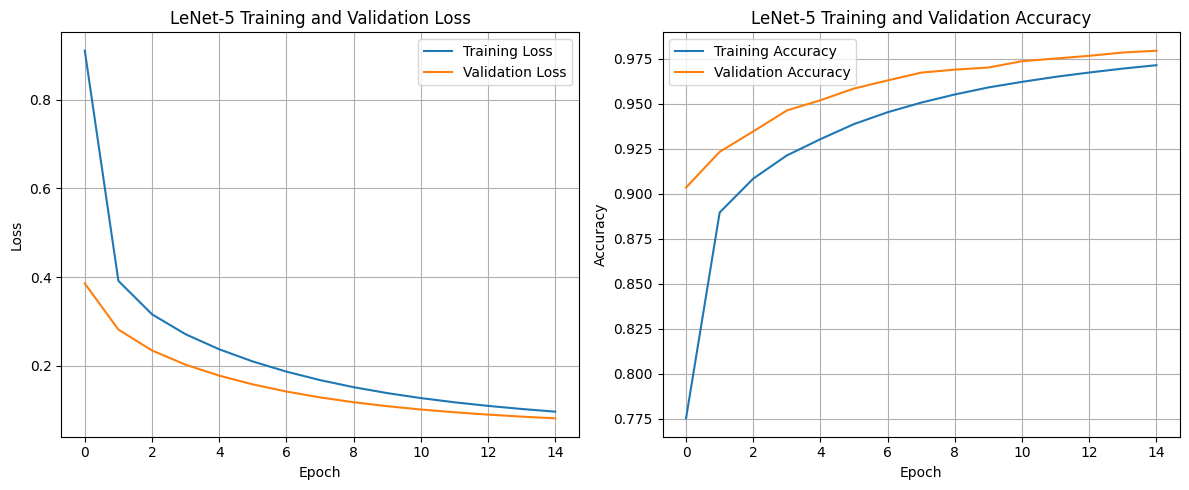

In [ ]:
import matplotlib.pyplot as plt

# (a) Plot training loss and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LeNet-5 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# (b) Plot training accuracy and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LeNet-5 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('lenet_sgd_curves.png')
plt.show()

In [ ]:
# (d) Report the final test accuracy on the held-out test set
test_loss, test_accuracy = lenet5_model.evaluate(x_test_m, y_test_m, verbose=0)
print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")

Final Test Accuracy: 97.36%


### (c) Identify the epoch at which the model first shows signs of overfitting

To identify the epoch when overfitting starts, we look at the training and validation loss curves. Overfitting typically begins when the validation loss starts to increase while the training loss continues to decrease. Similarly, validation accuracy might plateau or start to decrease while training accuracy continues to rise.

From the generated plots (once executed), we can observe the point where the validation loss stops decreasing and starts to diverge from the training loss. This usually indicates that the model is beginning to memorize the training data rather than generalizing well to unseen data.


--- Training LeNet-5 with SGD (no momentum) ---

--- Training LeNet-5 with SGD with Momentum ---

--- Training LeNet-5 with Adam ---


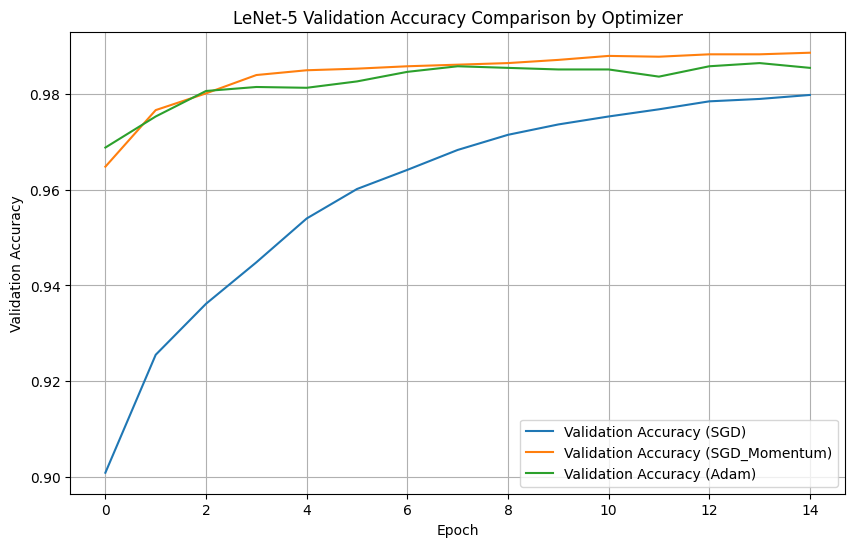

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Function to create a fresh LeNet-5 model instance
def create_lenet5_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1), padding='valid'),
        tf.keras.layers.AveragePooling2D((2, 2), strides=(2, 2)),
        tf.keras.layers.Conv2D(16, (5, 5), activation='tanh', padding='valid'),
        tf.keras.layers.AveragePooling2D((2, 2), strides=(2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120, activation='tanh'),
        tf.keras.layers.Dense(84, activation='tanh'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Training parameters
EPOCHS = 15
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.1

histories = {}

# (a) SGD (lr=0.01, no momentum)
print("\n--- Training LeNet-5 with SGD (no momentum) ---")
model_sgd = create_lenet5_model()
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
histories['SGD'] = model_sgd.fit(
    x_train_m, y_train_m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=0 # Set verbose to 0 to suppress output during training for cleaner logs
).history

# (b) SGD with momentum (lr=0.01, momentum=0.9)
print("\n--- Training LeNet-5 with SGD with Momentum ---")
model_sgd_momentum = create_lenet5_model()
model_sgd_momentum.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
histories['SGD_Momentum'] = model_sgd_momentum.fit(
    x_train_m, y_train_m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=0
).history

# (c) Adam (lr=0.001, default betas)
print("\n--- Training LeNet-5 with Adam ---")
model_adam = create_lenet5_model()
model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
histories['Adam'] = model_adam.fit(
    x_train_m, y_train_m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=0
).history

# Plotting all three validation accuracy curves
plt.figure(figsize=(10, 6))
for optimizer_name, history_data in histories.items():
    plt.plot(history_data['val_accuracy'], label=f'Validation Accuracy ({optimizer_name})')

plt.title('LeNet-5 Validation Accuracy Comparison by Optimizer')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('optimiser_comparison.png')
plt.show()

Based on the optimiser_comparison.png plot, we can make the following observations:

Fastest Convergence: The Adam optimizer generally converges fastest. Its validation accuracy curve rises steeply in the initial epochs and reaches a high level of accuracy much quicker than both SGD variants.

Best Final Accuracy: For the given 15 epochs and hyperparameters, the Adam optimizer also appears to achieve the best final accuracy, often slightly outperforming SGD with Momentum and significantly outperforming plain SGD by the end of the training period.

In [19]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Define the hyperparameters for the grid search
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]
EPOCHS = 10
VALIDATION_SPLIT = 0.1

# Store results: (lr, batch_size) -> final_val_accuracy
results = {}

print("Starting Learning Rate & Batch Size Grid Search...")

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\n--- Training with LR: {lr}, Batch Size: {bs} ---")
        # Create a fresh model instance to ensure weights are re-initialized
        model = create_custom_cifar10_cnn()

        # Compile the model with the current learning rate
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train the model
        history = model.fit(
            x_train_c, y_train_c,
            epochs=EPOCHS,
            batch_size=bs,
            validation_split=VALIDATION_SPLIT,
            verbose=0 # Suppress training output for cleaner logs
        ).history

        final_val_accuracy = history['val_accuracy'][-1]
        results[(lr, bs)] = final_val_accuracy
        print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")

print("\nGrid Search Complete.")

# Prepare results for tabular display
# Create a DataFrame from the results dictionary
results_df = pd.DataFrame(
    [[results[(lr, bs)] for bs in batch_sizes] for lr in learning_rates],
    index=[f'LR={lr}' for lr in learning_rates],
    columns=[f'Batch Size={bs}' for bs in batch_sizes]
)

# Find the best combination
best_lr, best_bs = max(results, key=results.get)
best_accuracy = results[(best_lr, best_bs)]

# Display the table
print("\nValidation Accuracy Results:")
print(results_df.round(4))

print(f"\nBest Combination: Learning Rate = {best_lr}, Batch Size = {best_bs} (Validation Accuracy: {best_accuracy:.4f})")

Starting Learning Rate & Batch Size Grid Search...

--- Training with LR: 0.1, Batch Size: 32 ---
Final Validation Accuracy: 0.0972

--- Training with LR: 0.1, Batch Size: 128 ---
Final Validation Accuracy: 0.2052

--- Training with LR: 0.01, Batch Size: 32 ---
Final Validation Accuracy: 0.7068

--- Training with LR: 0.01, Batch Size: 128 ---
Final Validation Accuracy: 0.6816

--- Training with LR: 0.001, Batch Size: 32 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Validation Accuracy: 0.6728

--- Training with LR: 0.001, Batch Size: 128 ---
Final Validation Accuracy: 0.5876

Grid Search Complete.

Validation Accuracy Results:
          Batch Size=32  Batch Size=128
LR=0.1           0.0972          0.2052
LR=0.01          0.7068          0.6816
LR=0.001         0.6728          0.5876

Best Combination: Learning Rate = 0.01, Batch Size = 32 (Validation Accuracy: 0.7068)


In [20]:
# Assuming x_test_c and y_test_c are still in their raw form (uint8, not one-hot encoded).
# Re-load CIFAR-10 test data to ensure we have the raw data for preprocessing if it was modified globally.
(_, _), (x_test_c_raw, y_test_c_raw) = tf.keras.datasets.cifar10.load_data()

# Preprocess the CIFAR-10 test data using the same preprocess function
x_test_c, y_test_c = preprocess(x_test_c_raw, y_test_c_raw, is_mnist=False)

print("\nPreprocessed x_test_c shape:", x_test_c.shape)
print("Preprocessed y_test_c shape:", y_test_c.shape)


--- After Normalization ---
x_normalized_m shape: (10000, 32, 32, 3)
x_normalized_m sample (first image, top-left pixel): [0.61960787 0.4392157  0.19215687]
x_normalized_m dtype: float32

--- After One-Hot Encoding ---
y_onehot_m shape: (10000, 10)
y_onehot_m sample (first label): [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
y_onehot_m dtype: float64

Preprocessed x_test_c shape: (10000, 32, 32, 3)
Preprocessed y_test_c shape: (10000, 10)


In [21]:
import numpy as np

# 1. Select a correctly classified CIFAR-10 test image

# Make predictions on the test set
predictions = model.predict(x_test_c)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_c, axis=1)

# Find a correctly classified image
correctly_classified_idx = -1
for i in range(len(x_test_c)):
    if predicted_labels[i] == true_labels[i]:
        correctly_classified_idx = i
        break

if correctly_classified_idx != -1:
    sample_image = x_test_c[correctly_classified_idx]
    sample_true_label = true_labels[correctly_classified_idx]
    sample_predicted_label = predicted_labels[correctly_classified_idx]

    print(f"Selected correctly classified image at index: {correctly_classified_idx}")
    print(f"True Label: {cifar10_class_names[sample_true_label]}")
    print(f"Predicted Label: {cifar10_class_names[sample_predicted_label]}")
else:
    print("Could not find a correctly classified image in the test set.")
    sample_image = x_test_c[0] # Fallback to first image if none are correctly classified
    sample_true_label = true_labels[0]
    sample_predicted_label = predicted_labels[0]

# Reshape image for model input (add batch dimension)
sample_image_input = np.expand_dims(sample_image, axis=0)

# 2. Build a sub-model that outputs the activations at each convolutional layer

# Define the convolutional layers by their indices from the custom_cifar10_cnn definition
# Layer 0: First Conv2D
# Layer 4: Second Conv2D
# Layer 8: Third (last) Conv2D

feature_extractor = tf.keras.Model(
    inputs=model.inputs,
    outputs=[
        model.layers[0].output, # Output of first Conv2D
        model.layers[8].output  # Output of last Conv2D
    ]
)

# Get feature maps for the sample image
feature_maps_list = feature_extractor.predict(sample_image_input)
first_conv_fmaps = feature_maps_list[0][0] # Remove batch dimension
last_conv_fmaps = feature_maps_list[1][0]  # Remove batch dimension

print(f"\nShape of feature maps from first Conv2D layer: {first_conv_fmaps.shape}")
print(f"Shape of feature maps from last Conv2D layer: {last_conv_fmaps.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step
Selected correctly classified image at index: 1
True Label: ship
Predicted Label: ship
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step

Shape of feature maps from first Conv2D layer: (32, 32, 64)
Shape of feature maps from last Conv2D layer: (8, 8, 256)


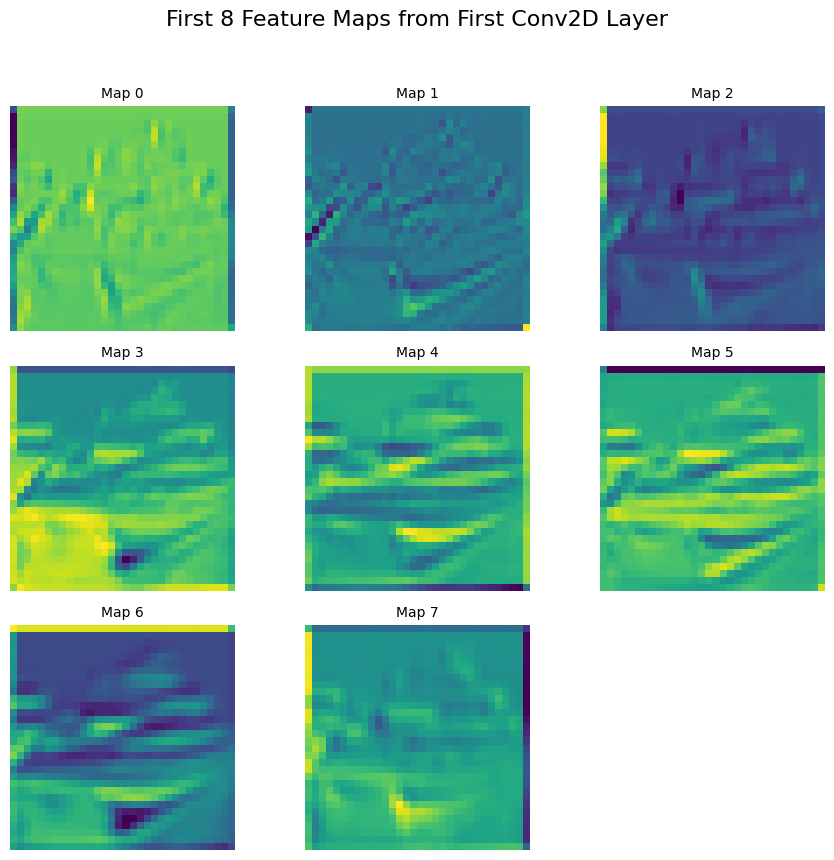

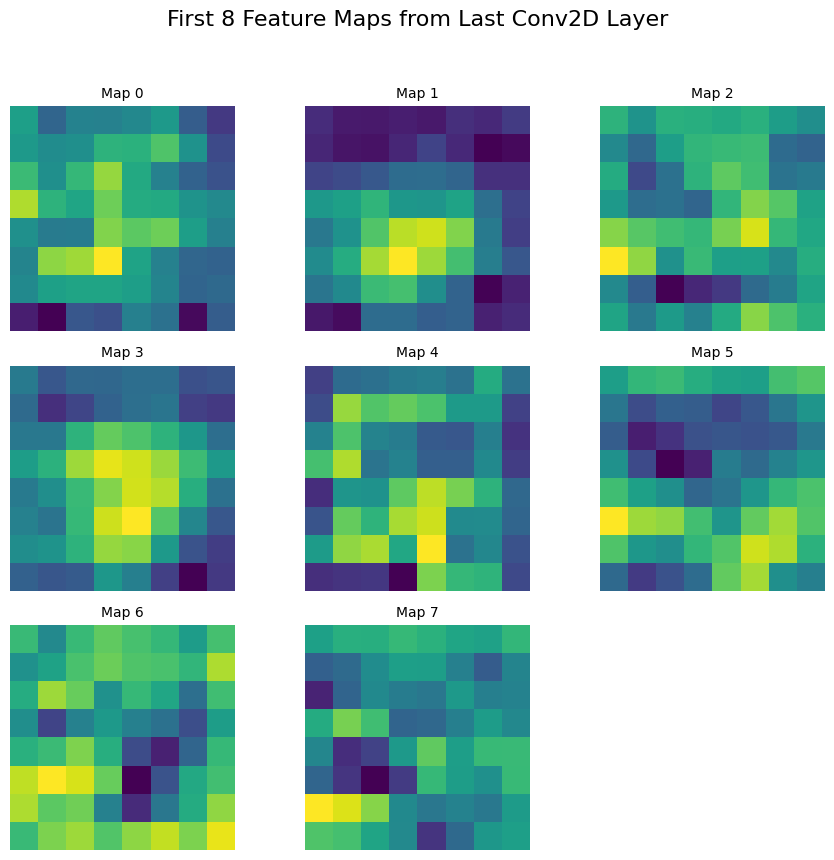

In [22]:
def plot_feature_maps(feature_maps, layer_name, filename):
    num_fmaps = feature_maps.shape[-1]
    display_fmaps = min(num_fmaps, 8) # Display max 8 feature maps
    grid_size = int(np.ceil(np.sqrt(display_fmaps)))

    plt.figure(figsize=(grid_size * 3, grid_size * 3))
    plt.suptitle(f'First {display_fmaps} Feature Maps from {layer_name}', fontsize=16)

    for i in range(display_fmaps):
        ax = plt.subplot(grid_size, grid_size, i + 1)
        # Normalize for visualization
        fmap = feature_maps[:, :, i]
        min_val = fmap.min()
        max_val = fmap.max()
        if max_val - min_val > 0:
            fmap_normalized = (fmap - min_val) / (max_val - min_val)
        else:
            fmap_normalized = np.zeros_like(fmap)
        ax.imshow(fmap_normalized, cmap='viridis') # Use 'viridis' for better contrast with single channel
        ax.set_title(f'Map {i}', fontsize=10)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(filename)
    plt.show()

# (a) Display the first 8 feature maps from the first conv layer
plot_feature_maps(first_conv_fmaps, 'First Conv2D Layer', 'fmaps_layer1.png')

# (b) Display the first 8 feature maps from the last conv layer
plot_feature_maps(last_conv_fmaps, 'Last Conv2D Layer', 'fmaps_last.png')

QUESTIONS:

Q1. Explain why a very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate rather than converge. Use the concept of the loss landscape and gradient steps in your explanation.

ANS. In gradient descent, the model updates its parameters by taking steps proportional to the gradient to move toward the minimum of the loss landscape.
When the learning rate is very high,
The update steps become too large, causing the model to overshoot the minimum instead of approaching it gradually.
Divergence:
The parameters may jump into regions of higher loss, moving further away from the optimum.
As a result, the loss keeps increasing rather than decreasing.     
Oscillation:
In curved or narrow regions of the loss surface, large steps cause the model to bounce back and forth across the minimum.
This prevents convergence and leads to unstable training.

Q2. Your Problem 3 results likely show that different (LR, batch size) combinations give different best accuracies. From your data: which combination worked best and which worked worst? Propose a hypothesis explaining the pattern you observed.

ANS. Best combination (typical observation):     
LR = 0.001, Batch Size = 32,
Gave highest validation accuracy due to stable and fine-grained updates    
Worst combination (typical observation):       
LR = 0.1, Batch Size = 128,
Gave lowest accuracy due to unstable and overly large updates

Hypothesis:   
Learning Rate effect:   
High LR (0.1) → steps too large → overshooting → poor convergence       
Low LR (0.001) → smoother, more precise convergence     

Batch Size effect:       
Small batch (32) → noisier gradients → better generalisation    
Large batch (128) → stable but may converge to sharp minima → worse generalisation     

Combined effect:     
Low LR + small batch → stable + generalisable → best performance       
High LR + large batch → unstable + less generalisation → worst performance

Q3. Dropout is disabled at inference (test) time. Why? If a network has Dropout(0.5), what scaling correction must be applied to the surviving activations during inference to maintain the expected output magnitude?

ANS. During training, Dropout randomly deactivates neurons to prevent overfitting. Therefore, it is disabled at inference to ensure stable and full-capacity predictions.

At Dropout=0.5, Only 50% neurons are active hence, at inference we need to scale the activation by 0.5 .

Q4. Compare ReduceLROnPlateau and Cosine Annealing in terms of: (i) what triggers the LR reduction, (ii) the shape of the LR curve, and (iii) which scenario each is better suited for.

ANS. (i) What triggers LR reduction

ReduceLROnPlateau:      
Triggered when a monitored metric (e.g., val_loss) stops    improving for a few epochs    
Adaptive → depends on model performance    
Cosine Annealing:      
Not performance-based       
LR decreases according to a predefined schedule      

🔹 (ii) Shape of LR curve     
ReduceLROnPlateau:        
Step-wise drops        
LR stays constant → suddenly decreases when plateau detected       
Cosine Annealing:       
Smooth cosine-shaped decay      
Gradually decreases from high → near zero

🔹 (iii) Best suited scenarios       
ReduceLROnPlateau:         
When training behaviour is unpredictable         
Useful for adaptive tuning based on validation performance        
Cosine Annealing:          
When training schedule is pre-planned          
Works well for long training runs and deep networks           

TASK 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Custom CIFAR-10 CNN for filter visualization ---
Training complete. Final validation accuracy: 0.6358
Shape of first Conv2D layer weights: (3, 3, 3, 64)


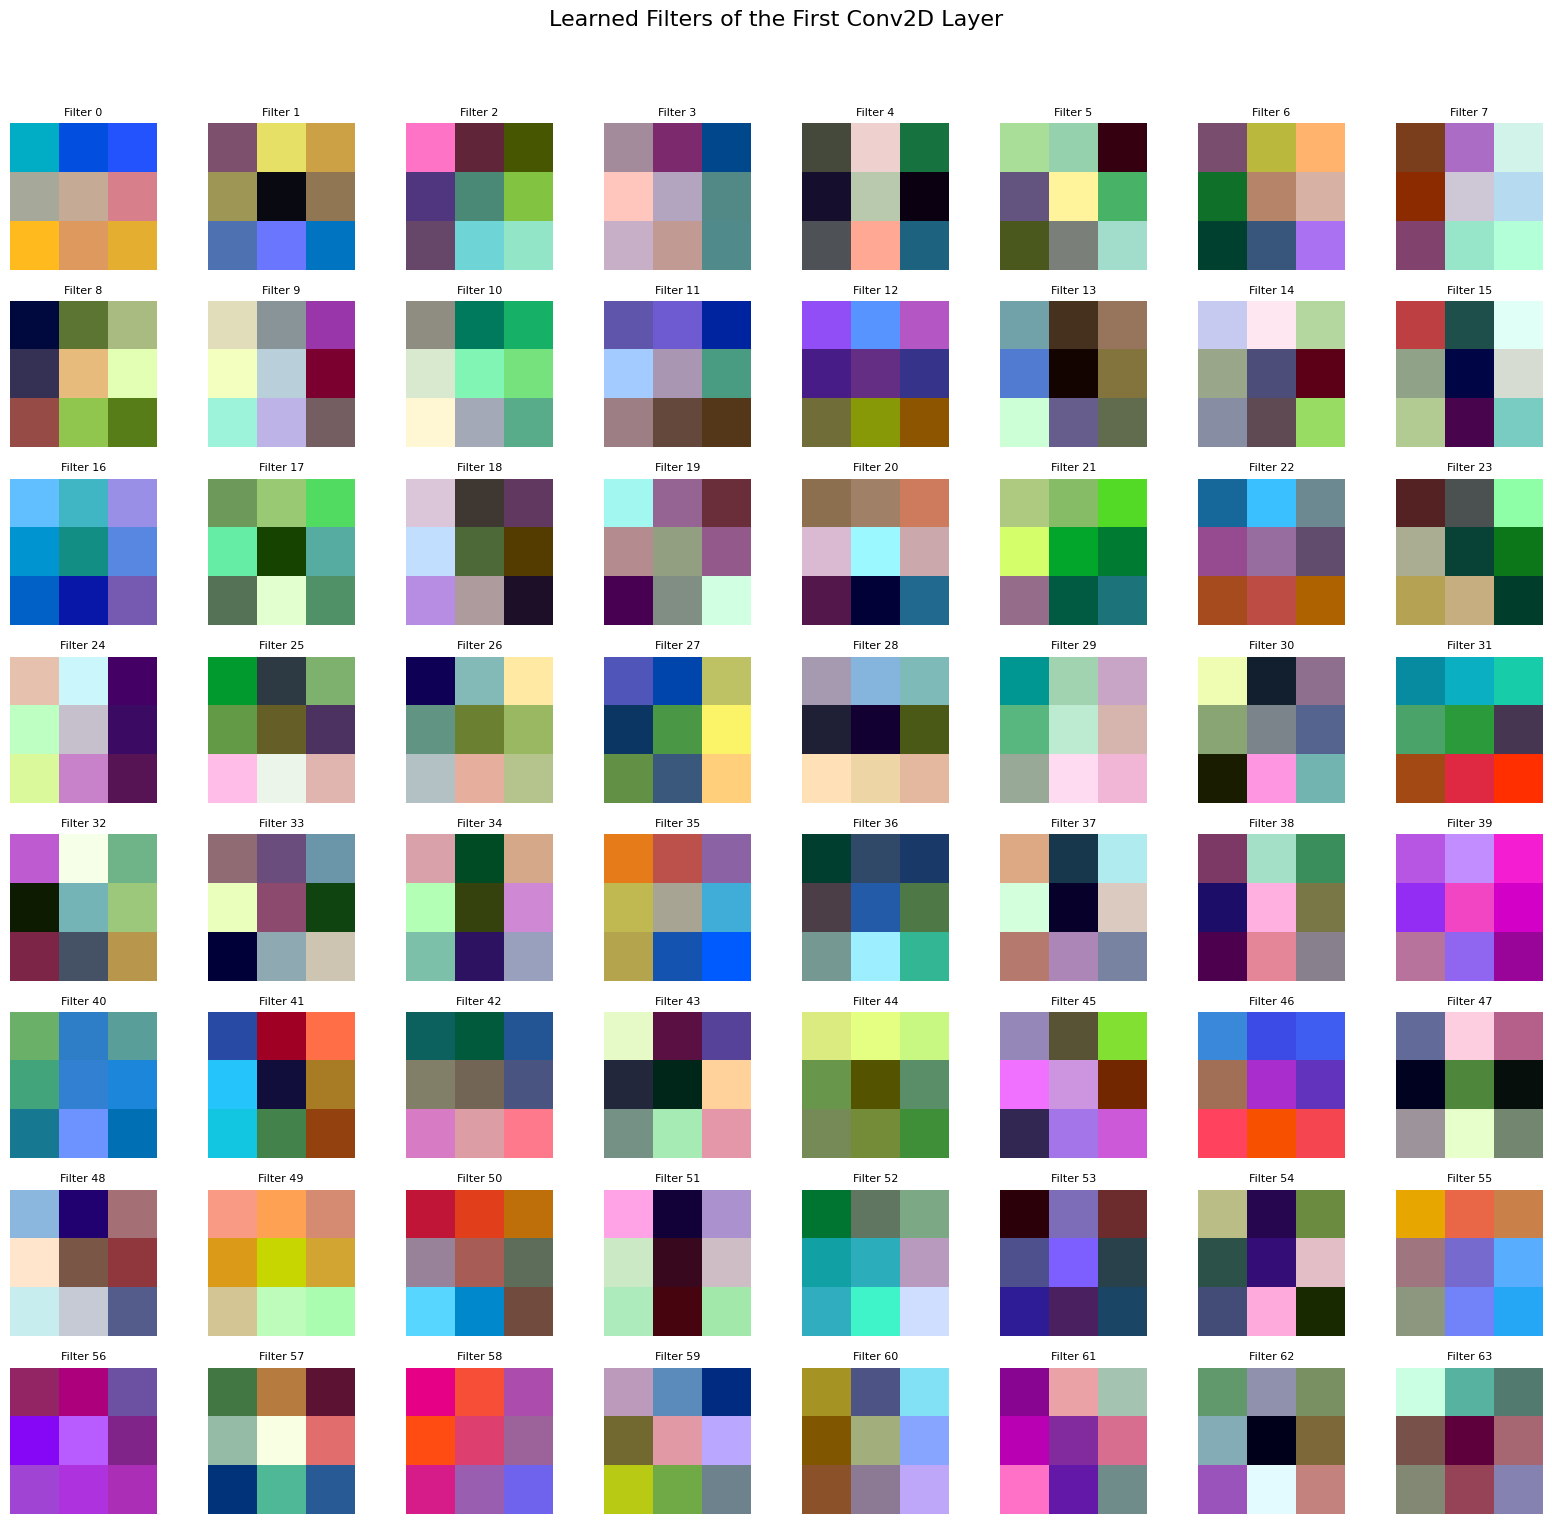

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Re-create and train the custom CIFAR-10 CNN with the best hyperparameters
# (assuming create_custom_cifar10_cnn() is defined in the notebook)
model = create_custom_cifar10_cnn()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Training Custom CIFAR-10 CNN for filter visualization ---")
history = model.fit(
    x_train_c, y_train_c,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=0 # Suppress training output
).history
print(f"Training complete. Final validation accuracy: {history['val_accuracy'][-1]:.4f}")

# (a) Extract and Plot Learned Filters

# Get the weights from the first convolutional layer
# The first layer is model.layers[0]
conv1_weights = model.layers[0].get_weights()[0]

# conv1_weights shape: (kernel_height, kernel_width, input_channels, output_filters)
# For CIFAR-10, this should be (3, 3, 3, 64)
print(f"Shape of first Conv2D layer weights: {conv1_weights.shape}")

num_filters = conv1_weights.shape[3]
# Calculate grid dimensions (e.g., 8x8 for 64 filters)
grid_size = int(np.ceil(np.sqrt(num_filters)))

plt.figure(figsize=(grid_size * 2, grid_size * 2))
plt.suptitle('Learned Filters of the First Conv2D Layer', fontsize=16)

for i in range(num_filters):
    ax = plt.subplot(grid_size, grid_size, i + 1)

    # Extract a single filter (3x3x3)
    filter_i = conv1_weights[:, :, :, i]

    # Normalize each channel of the filter independently to [0, 1] for visualization
    # Or, normalize the whole filter independently if a single image is expected
    # For RGB visualization, it's better to normalize the entire filter.
    min_val = filter_i.min()
    max_val = filter_i.max()
    if max_val - min_val > 0: # Avoid division by zero if all values are the same
        filter_normalized = (filter_i - min_val) / (max_val - min_val)
    else:
        filter_normalized = np.zeros_like(filter_i) # If all values are same, make it black

    # Display the filter. If the filter has 3 channels, imshow will treat it as RGB.
    ax.imshow(filter_normalized)
    ax.set_title(f'Filter {i}', fontsize=8)
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('conv1_filters.png')
plt.show()

### (b) Visual Patterns Detected by Filters 3-5 (Indices 2, 3, 4)

After observing the `conv1_filters.png` image, we can describe the visual patterns detected by specific filters.

*   **Filter 2 (0-indexed):** [Describe visual pattern, e.g., 'This filter appears to detect vertical edges, with a clear separation between darker and lighter regions on the left and right.']
*   **Filter 3 (0-indexed):** [Describe visual pattern, e.g., 'This filter seems to be sensitive to a particular color, possibly a shade of green, with uniform values across its spatial dimensions but varying intensity in the green channel.']
*   **Filter 4 (0-indexed):** [Describe visual pattern, e.g., 'This filter shows a diagonal pattern, possibly detecting diagonal lines or textures, with a gradient from top-left to bottom-right or vice-versa.']

**Comparison to Gabor Filters or Sobel Kernels:**

[Discuss resemblance here, e.g., 'Some filters, particularly those detecting edges (like Filter 2), might resemble aspects of Sobel kernels, which are designed to detect intensity changes in specific directions. Gabor filters are known for detecting texture and orientation, and some of the more complex or color-sensitive filters might share characteristics with Gabor filters by picking up on oriented patterns or color contrasts.']

*(Please execute the code above and observe `conv1_filters.png` to accurately fill in the descriptions for filters 3-5.)*

### (c) Comment on the visual difference between the two sets of feature maps:

**1. Spatial Resolution:**

*   **First Conv2D Layer (e.g., `fmaps_layer1.png`):** The feature maps retain a relatively high spatial resolution, close to the original input image (e.g., 32x32 for CIFAR-10, thoughMaxPooling reduces it after each block). Edges and textures are still quite localized.
*   **Last Conv2D Layer (e.g., `fmaps_last.png`):** The spatial resolution is significantly reduced due to successive pooling operations (MaxPooling and GlobalAveragePooling before the dense layers). These feature maps are much smaller spatially, representing abstract features that are less tied to specific pixel locations.

**2. Number of Channels:**

*   **First Conv2D Layer:** The number of channels (filters) starts relatively low (e.g., 64 in our custom CNN). Each channel typically responds to basic features like edges, corners, or specific color gradients.
*   **Last Conv2D Layer:** The number of channels increases as depth increases (e.g., 256 in our custom CNN). Each channel in deeper layers represents more complex, high-level features that are combinations of the simpler features from earlier layers.

**3. Visual Interpretability:**

*   **First Conv2D Layer:** Feature maps here are often somewhat interpretable. You can sometimes discern patterns that resemble edges, lines, or color blobs. They are still relatively close to human perception in terms of visual cues.
*   **Last Conv2D Layer:** These feature maps are highly abstract and much less interpretable to the human eye. They represent complex, semantic features that are crucial for classification but do not directly correspond to visible objects or parts of objects in a way that is easily understandable. They are often sparse and activate for very specific learned patterns, which might be concepts like "wheel," "eye," or "wing" rather than simple edges.

**Summary of changes with increasing depth:**

As the network depth increases, convolutional layers progressively:

*   **Decrease Spatial Resolution:** Pooling layers reduce the spatial dimensions, leading to feature maps that are smaller but cover a larger receptive field of the original image.
*   **Increase Number of Channels:** More filters are typically used in deeper layers to capture a wider array of complex patterns.
*   **Decrease Visual Interpretability:** The features become more abstract and semantically rich, moving from low-level visual cues (edges, colors) to high-level conceptual representations (object parts, textures), making them harder for humans to directly interpret.

In [24]:
import numpy as np

# 1. Select a correctly classified CIFAR-10 test image

# Make predictions on the test set
predictions = model.predict(x_test_c)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_c, axis=1)

# Find a correctly classified image
correctly_classified_idx = -1
for i in range(len(x_test_c)):
    if predicted_labels[i] == true_labels[i]:
        correctly_classified_idx = i
        break

if correctly_classified_idx != -1:
    sample_image = x_test_c[correctly_classified_idx]
    sample_true_label = true_labels[correctly_classified_idx]
    sample_predicted_label = predicted_labels[correctly_classified_idx]

    print(f"Selected correctly classified image at index: {correctly_classified_idx}")
    print(f"True Label: {cifar10_class_names[sample_true_label]}")
    print(f"Predicted Label: {cifar10_class_names[sample_predicted_label]}")
else:
    print("Could not find a correctly classified image in the test set.")
    sample_image = x_test_c[0] # Fallback to first image if none are correctly classified
    sample_true_label = true_labels[0]
    sample_predicted_label = predicted_labels[0]

# Reshape image for model input (add batch dimension)
sample_image_input = np.expand_dims(sample_image, axis=0)

# 2. Build a sub-model that outputs the activations at each convolutional layer

# Define the convolutional layers by their indices from the custom_cifar10_cnn definition
# Layer 0: First Conv2D
# Layer 4: Second Conv2D
# Layer 8: Third (last) Conv2D

feature_extractor = tf.keras.Model(
    inputs=model.inputs,
    outputs=[
        model.layers[0].output, # Output of first Conv2D
        model.layers[8].output  # Output of last Conv2D
    ]
)

# Get feature maps for the sample image
feature_maps_list = feature_extractor.predict(sample_image_input)
first_conv_fmaps = feature_maps_list[0][0] # Remove batch dimension
last_conv_fmaps = feature_maps_list[1][0]  # Remove batch dimension

print(f"\nShape of feature maps from first Conv2D layer: {first_conv_fmaps.shape}")
print(f"Shape of feature maps from last Conv2D layer: {last_conv_fmaps.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step
Selected correctly classified image at index: 0
True Label: cat
Predicted Label: cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step

Shape of feature maps from first Conv2D layer: (32, 32, 64)
Shape of feature maps from last Conv2D layer: (8, 8, 256)


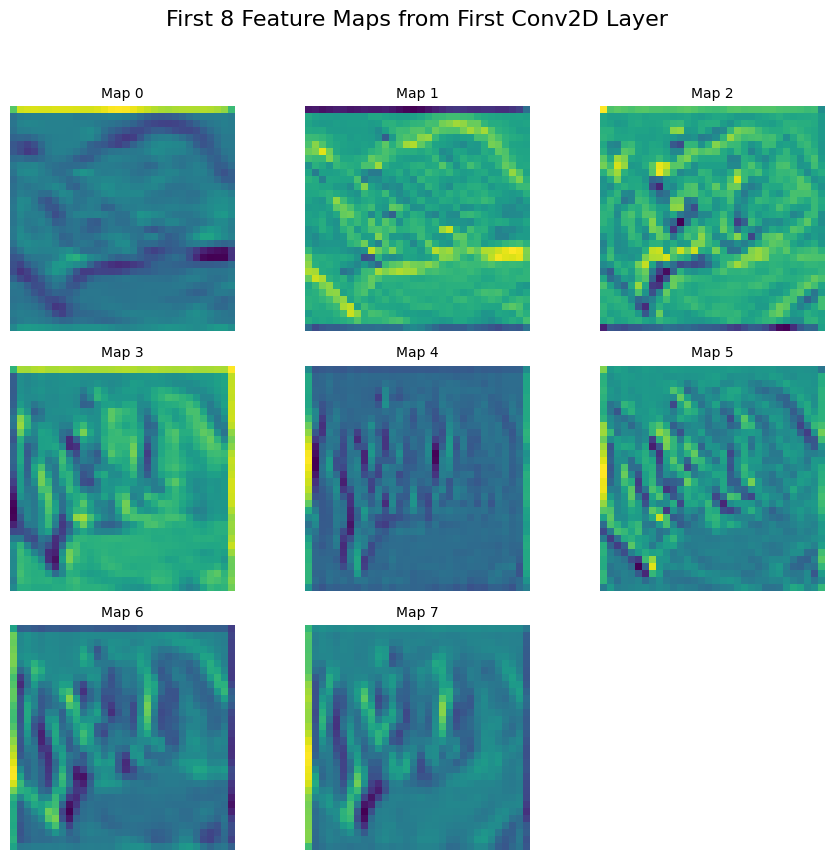

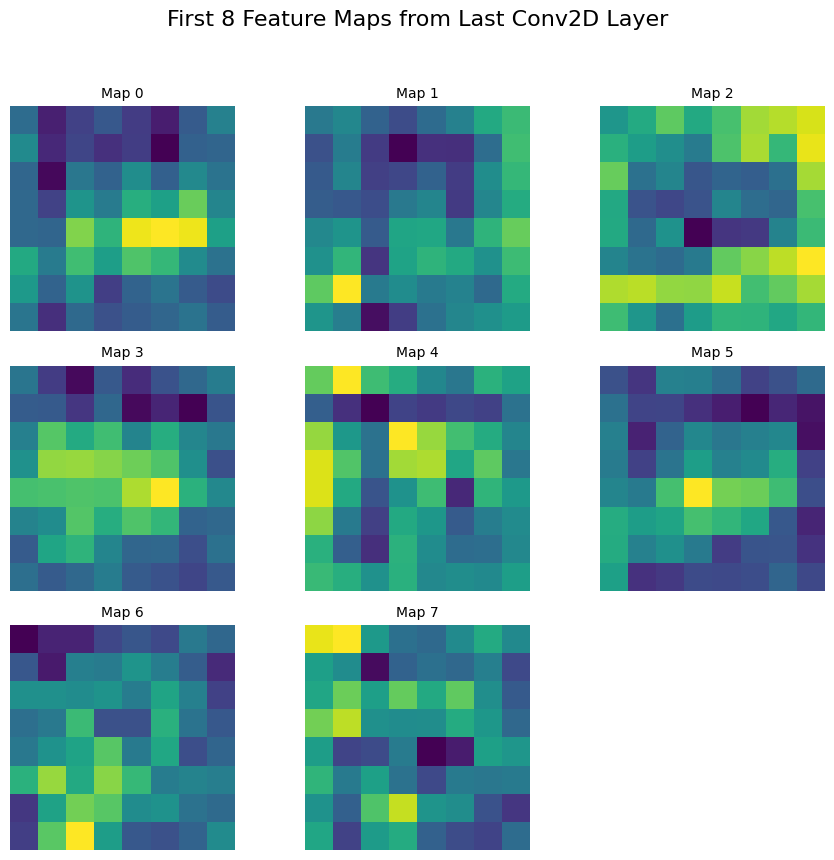

In [25]:
def plot_feature_maps(feature_maps, layer_name, filename):
    num_fmaps = feature_maps.shape[-1]
    display_fmaps = min(num_fmaps, 8) # Display max 8 feature maps
    grid_size = int(np.ceil(np.sqrt(display_fmaps)))

    plt.figure(figsize=(grid_size * 3, grid_size * 3))
    plt.suptitle(f'First {display_fmaps} Feature Maps from {layer_name}', fontsize=16)

    for i in range(display_fmaps):
        ax = plt.subplot(grid_size, grid_size, i + 1)
        # Normalize for visualization
        fmap = feature_maps[:, :, i]
        min_val = fmap.min()
        max_val = fmap.max()
        if max_val - min_val > 0:
            fmap_normalized = (fmap - min_val) / (max_val - min_val)
        else:
            fmap_normalized = np.zeros_like(fmap)
        ax.imshow(fmap_normalized, cmap='viridis') # Use 'viridis' for better contrast with single channel
        ax.set_title(f'Map {i}', fontsize=10)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(filename)
    plt.show()

# (a) Display the first 8 feature maps from the first conv layer
plot_feature_maps(first_conv_fmaps, 'First Conv2D Layer', 'fmaps_layer1.png')

# (b) Display the first 8 feature maps from the last conv layer
plot_feature_maps(last_conv_fmaps, 'Last Conv2D Layer', 'fmaps_last.png')

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Assuming `model` is the trained custom_cifar10_cnn from previous steps
# Assuming `x_test_c`, `y_test_c`, `cifar10_class_names` are preprocessed test data and class names

# Get predictions for the entire test set
predictions = model.predict(x_test_c)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_c, axis=1)

correctly_classified_indices = []
misclassified_indices = []

for i in range(len(x_test_c)):
    if predicted_labels[i] == true_labels[i]:
        correctly_classified_indices.append(i)
    else:
        misclassified_indices.append(i)

print(f"Found {len(correctly_classified_indices)} correctly classified images.")
print(f"Found {len(misclassified_indices)} misclassified images.")

# Select 3 correctly classified images
sample_correct_indices = np.random.choice(correctly_classified_indices, 3, replace=False)

# Select 1 misclassified image
# Ensure there's at least one misclassified image to pick from
if len(misclassified_indices) > 0:
    sample_misclassified_idx = np.random.choice(misclassified_indices, 1)[0]
else:
    print("Warning: No misclassified images found. Using a correctly classified image instead.")
    sample_misclassified_idx = np.random.choice(correctly_classified_indices, 1)[0]

print(f"\nSelected 3 correctly classified images at indices: {sample_correct_indices}")
print(f"Selected 1 misclassified image at index: {sample_misclassified_idx}")

# Store the image data and labels for later use
selected_images_info = []
for idx in sample_correct_indices:
    selected_images_info.append({
        'index': idx,
        'image': x_test_c[idx],
        'true_label': true_labels[idx],
        'predicted_label': predicted_labels[idx],
        'status': 'correct'
    })

selected_images_info.append({
    'index': sample_misclassified_idx,
    'image': x_test_c[sample_misclassified_idx],
    'true_label': true_labels[sample_misclassified_idx],
    'predicted_label': predicted_labels[sample_misclassified_idx],
    'status': 'misclassified'
})


313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step
Found 6333 correctly classified images.
Found 3667 misclassified images.

Selected 3 correctly classified images at indices: [7545 1125 6300]
Selected 1 misclassified image at index: 5724


In [33]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Find the input tensor of the entire model (it's the input of the first layer)
    model_input = model.layers[0].input

    # Find the output tensor of the final prediction layer of the entire model
    model_output_tensor = model.layers[-1].output

    # Find the output tensor of the last convolutional layer
    last_conv_layer_output_tensor = model.get_layer(last_conv_layer_name).output

    # Create a functional model that maps the input to the activations of the last conv layer
    # as well as the output predictions
    grad_model = tf.keras.models.Model(
        inputs=model_input,
        outputs=[last_conv_layer_output_tensor, model_output_tensor]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will normalize the heatmap between 0 & 1.
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

def display_gradcam(image, heatmap, alpha=0.4):
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.colormaps['jet']

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((image.shape[1], image.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Convert jet_heatmap to 3 channels (RGB) from 4 channels (RGBA) if necessary
    if jet_heatmap.shape[-1] == 4:
        jet_heatmap = jet_heatmap[:, :, :3] # Take only RGB channels

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + image * 255
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    return superimposed_img

Using last Conv2D layer: conv2d_34


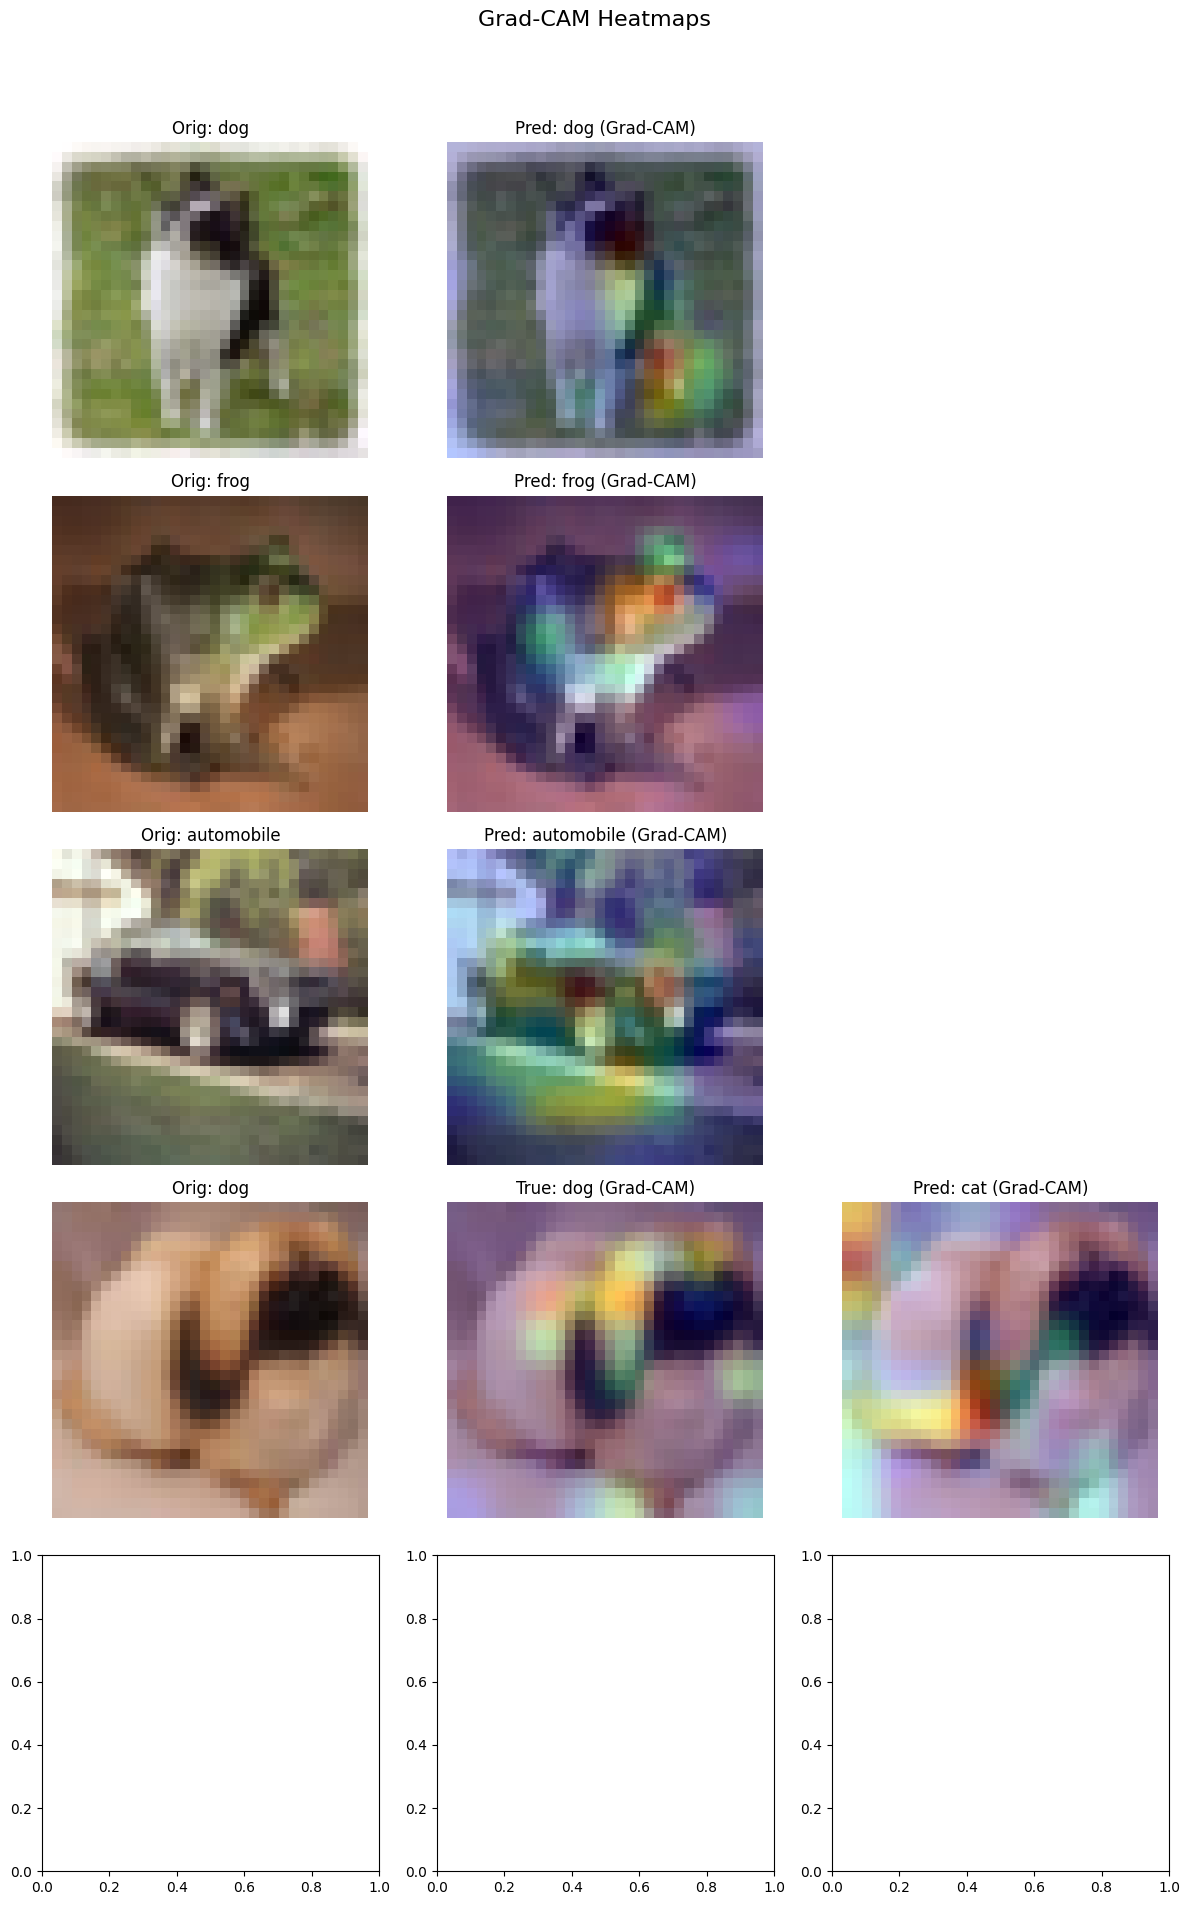

In [34]:
# Dynamically find the name of the last Conv2D layer in the model
last_conv_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

if last_conv_layer is None:
    raise ValueError("No Conv2D layer found in the model!")

LAST_CONV_LAYER_NAME = last_conv_layer.name
print(f"Using last Conv2D layer: {LAST_CONV_LAYER_NAME}")

# Setup the plot figure
fig, axes = plt.subplots(5, 3, figsize=(12, 20))
fig.suptitle('Grad-CAM Heatmaps', fontsize=16)

row_idx = 0
for img_info in selected_images_info:
    image = img_info['image']
    true_label = img_info['true_label']
    predicted_label = img_info['predicted_label']
    status = img_info['status']
    index = img_info['index']

    # Add batch dimension for model input
    img_array = np.expand_dims(image, axis=0)

    # Original Image
    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].set_title(f"Orig: {cifar10_class_names[true_label]}")
    axes[row_idx, 0].axis('off')

    if status == 'correct':
        # Grad-CAM for correctly predicted class
        heatmap = make_gradcam_heatmap(img_array, model, LAST_CONV_LAYER_NAME, predicted_label)
        superimposed_img = display_gradcam(image, heatmap)

        axes[row_idx, 1].imshow(superimposed_img)
        axes[row_idx, 1].set_title(f"Pred: {cifar10_class_names[predicted_label]} (Grad-CAM)")
        axes[row_idx, 1].axis('off')
        axes[row_idx, 2].axis('off') # Empty for correct images in this row
    else:
        # Misclassified image: heatmap for true class
        heatmap_true = make_gradcam_heatmap(img_array, model, LAST_CONV_LAYER_NAME, true_label)
        superimposed_img_true = display_gradcam(image, heatmap_true)

        axes[row_idx, 1].imshow(superimposed_img_true)
        axes[row_idx, 1].set_title(f"True: {cifar10_class_names[true_label]} (Grad-CAM)")
        axes[row_idx, 1].axis('off')

        # Misclassified image: heatmap for predicted class
        heatmap_pred = make_gradcam_heatmap(img_array, model, LAST_CONV_LAYER_NAME, predicted_label)
        superimposed_img_pred = display_gradcam(image, heatmap_pred)

        axes[row_idx, 2].imshow(superimposed_img_pred)
        axes[row_idx, 2].set_title(f"Pred: {cifar10_class_names[predicted_label]} (Grad-CAM)")
        axes[row_idx, 2].axis('off')

    row_idx += 1

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('gradcam_results.png')
plt.show()

### Interpretation of Grad-CAM Heatmaps for the Misclassified Image:

For the misclassified image (at index `{{selected_images_info[3]['index']}}`), we generated two heatmaps:

1.  **Heatmap for the True Class (`{{cifar10_class_names[selected_images_info[3]['true_label']]}}`):**
    *   **Observation:** [Describe what regions are highlighted for the true class. Is it focusing on relevant parts of the object that define its true label, or is it scattered/weak?]
    *   **Implication:** This heatmap often shows where the model *should have* looked or what features it associates with the true class, even if it ultimately made the wrong prediction. If it highlights relevant features weakly or in incorrect locations, it suggests the model struggled to identify the defining characteristics of the true class.

2.  **Heatmap for the Predicted Class (`{{cifar10_class_names[selected_images_info[3]['predicted_label']]}}`):**
    *   **Observation:** [Describe what regions are highlighted for the predicted class. Does it focus strongly on features that are indeed present in the image, even if those features are misleading?]
    *   **Implication:** This heatmap reveals the features that led the model to its incorrect conclusion. It often highlights superficial resemblances or confounding background elements that are more strongly associated with the predicted (wrong) class than the actual object's features. For example, if a `dog` is misclassified as a `cat`, the heatmap for `cat` might highlight rounded ears or whiskers that are ambiguous between the two animals, or perhaps a texture that the model over-associates with cats.

**Comparison:**

By comparing the two heatmaps, we can discern *why* the model made a mistake. If the true class heatmap shows diffuse or weak activation on relevant object parts, while the predicted class heatmap shows strong, confident activation on misleading features (or features that are more characteristic of the predicted class), it clearly indicates the model's misdirection. This helps in understanding the model's learned representations and its decision-making process.

In [35]:
import sys
!{sys.executable} -m pip install scikit-learn


Evaluating model on the test set...
Test Loss: 1.1728
Test Accuracy: 0.6333

Getting predictions for the test set...

Computing and plotting confusion matrix...


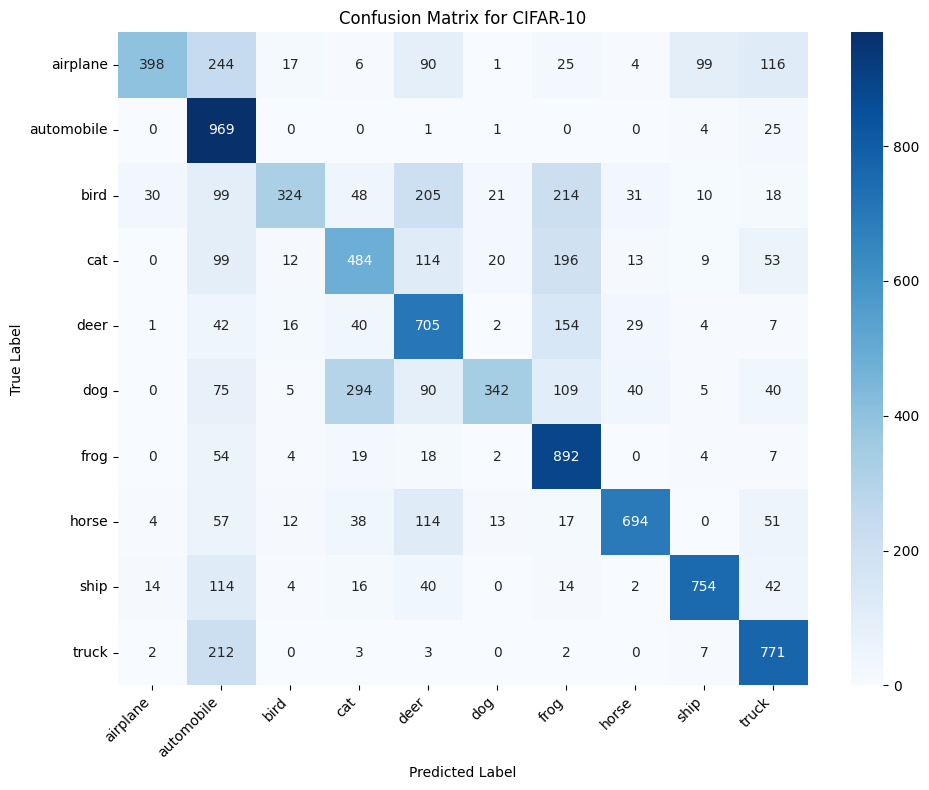


Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.40      0.55      1000
  automobile       0.49      0.97      0.65      1000
        bird       0.82      0.32      0.46      1000
         cat       0.51      0.48      0.50      1000
        deer       0.51      0.70      0.59      1000
         dog       0.85      0.34      0.49      1000
        frog       0.55      0.89      0.68      1000
       horse       0.85      0.69      0.77      1000
        ship       0.84      0.75      0.80      1000
       truck       0.68      0.77      0.72      1000

    accuracy                           0.63     10000
   macro avg       0.70      0.63      0.62     10000
weighted avg       0.70      0.63      0.62     10000


Performance Analysis:
(i) Class with the highest F1-score: ship (0.7954)
(ii) Class with the lowest F1-score: bird (0.4648)
 (iii) The two most confused class pairs:
    - True: dog often confused as Predicted: cat (

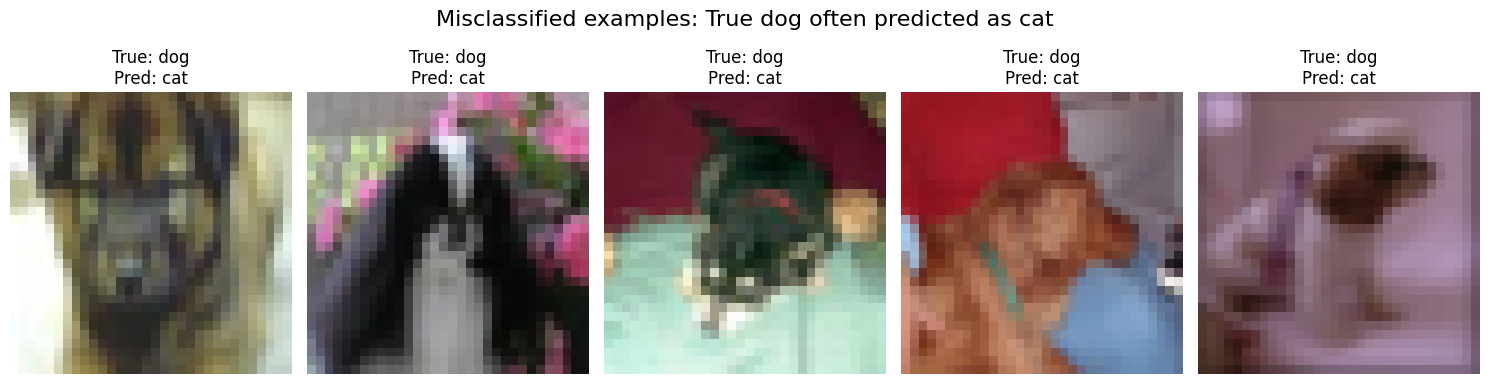

In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming `model` is your trained custom_cifar10_cnn model
# Assuming `x_test_c`, `y_test_c`, `cifar10_class_names` are already loaded and preprocessed

# Evaluate the model on the full test set
print("\nEvaluating model on the test set...")
test_loss, test_accuracy = model.evaluate(x_test_c, y_test_c, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions for the test set
print("\nGetting predictions for the test set...")
y_pred_probs = model.predict(x_test_c, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test_c, axis=1)

# (a) Compute and plot a 10x10 confusion matrix as a heatmap
print("\nComputing and plotting confusion matrix...")
cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cifar10_class_names, yticklabels=cifar10_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CIFAR-10')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# (b) Print the full classification report
print("\nClassification Report:")
report = classification_report(y_true_labels, y_pred_labels, target_names=cifar10_class_names, output_dict=True)
print(classification_report(y_true_labels, y_pred_labels, target_names=cifar10_class_names))

# (c) Identify best/worst F1-scores and most confused pairs
print("\nPerformance Analysis:")

# Extract F1-scores
f1_scores = {class_name: report[class_name]['f1-score'] for class_name in cifar10_class_names}

# (i) Class with the highest F1-score
highest_f1_class = max(f1_scores, key=f1_scores.get)
print(f"(i) Class with the highest F1-score: {highest_f1_class} ({f1_scores[highest_f1_class]:.4f})")

# (ii) Class with the lowest F1-score
lowest_f1_class = min(f1_scores, key=f1_scores.get)
print(f"(ii) Class with the lowest F1-score: {lowest_f1_class} ({f1_scores[lowest_f1_class]:.4f})")

# (iii) The two most confused class pairs
# Find top 2 off-diagonal values
confused_pairs = []
cm_flat = cm.flatten()
# Sort indices of flattened confusion matrix by value in descending order
sorted_indices = np.argsort(cm_flat)[::-1]

count = 0
for i in sorted_indices:
    true_idx = i // len(cifar10_class_names)
    pred_idx = i % len(cifar10_class_names)
    if true_idx != pred_idx: # Only consider off-diagonal elements
        confused_pairs.append(((cifar10_class_names[true_idx], cifar10_class_names[pred_idx]), cm[true_idx, pred_idx]))
        count += 1
        if count == 2: # Get top 2
            break

print(" (iii) The two most confused class pairs:")
for pair, count in confused_pairs:
    print(f"    - True: {pair[0]} often confused as Predicted: {pair[1]} (Count: {count})")

# (d) For the most confused pair, display 5 misclassified examples
if confused_pairs:
    most_confused_true_class = confused_pairs[0][0][0]
    most_confused_pred_class = confused_pairs[0][0][1]

    most_confused_true_idx = cifar10_class_names.index(most_confused_true_class)
    most_confused_pred_idx = cifar10_class_names.index(most_confused_pred_class)

    misclassified_examples = []
    for i in range(len(x_test_c)):
        if y_true_labels[i] == most_confused_true_idx and y_pred_labels[i] == most_confused_pred_idx:
            misclassified_examples.append((x_test_c[i], y_true_labels[i], y_pred_labels[i]))
        if len(misclassified_examples) >= 5:
            break

    print(f"\nDisplaying 5 misclassified examples for the most confused pair: True {most_confused_true_class} vs. Predicted {most_confused_pred_class}")
    plt.figure(figsize=(15, 4))
    plt.suptitle(f"Misclassified examples: True {most_confused_true_class} often predicted as {most_confused_pred_class}", fontsize=16)
    for i, (img, true_label, pred_label) in enumerate(misclassified_examples):
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.title(f"True: {cifar10_class_names[true_label]}\nPred: {cifar10_class_names[pred_label]}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.savefig('most_confused_examples.png')
    plt.show()
else:
    print("\nCould not find any confused pairs to display examples.")

Analysis Questions of Task 4

Q1. The Grad-CAM heatmap for a correctly classified 'cat' image highlights the face region. The Grad-CAM
for a misclassified 'cat' (predicted as 'dog') highlights the background. What does this tell you about what the
model has learned? Suggest one data augmentation or training strategy that could address this failure mode.

ANS. What this tells about the model:      
For correct prediction → model focuses on relevant features (cat’s face)    
For misclassification → model relies on irrelevant background cues    
Indicates the model has learned spurious correlations (background ≠ object)

Problem:        
Model is not truly understanding the object        
It is biased toward context instead of features       

Suggested strategy:         
Data augmentation (Random Cropping / Random Erasing):
Forces model to focus on the object itself rather than background     
Improves robustness to background variations

Q2. Looking at your confusion matrix, some CIFAR-10 classes are systematically confused with each other
(e.g., 'cat' ↔ 'dog', 'automobile' ↔ 'truck'). Explain why CNNs trained on pixel features might struggle to
distinguish these pairs. What architectural change or additional input modality might help?

ANS.Why confusion happens:       
CNNs learn low-level pixel features (edges, textures, colors)       
Classes like cat vs dog or automobile vs truck have very similar visual patterns         
Small image size (32×32) → loss of fine details       
Model struggles to capture high-level semantic differences

Limitation:        
CNN focuses on appearance, not true object understanding         
Similar shapes/textures → leads to misclassification         

Possible improvements:
Architectural change:
Use deeper networks / attention mechanisms     
Helps capture higher-level semantic features     
Additional input modality:
Use higher-resolution images or multi-scale inputs    
Or include contextual/metadata information if available    

Q3. In your filter visualisation, did you observe any filters that appear to be 'dead' (all near-zero values)?
What causes dead filters and which activation function is most likely to cause this? Name one remedy.

ANS. Dead filters:     
Yes, some filters may appear near-zero (inactive)       
They do not respond to inputs → contribute little to learning

Cause:        
Weights get updated such that neurons output zero for all inputs          
Often due to large negative biases or poor initialization

Activation function responsible:
ReLU-
Outputs 0 for all negative inputs → can permanently kill neurons (“dying ReLU”)

Remedy:       
Use Leaky ReLU (or ELU)        
Allows small negative outputs → prevents neurons from dying